# Facial Expression Recognition System
**Author:** Syed Taha Ali

An exploration of **polynomial feature expansion in fully-connected networks** applied to facial expression classification. Each neuron computes `net = W @ (x + x²)` — a quadratic activation that combines linear and squared input terms under a shared weight. The FC-only architecture deliberately excludes convolutional layers, isolating the contribution of the quadratic formula from spatial inductive bias.

**Task:** Classify 48×48 grayscale face images into 6 emotion classes: **Angry, Fear, Happy, Neutral, Sad, Surprise**.

---
## Notebook Structure
- **Section 0** - Imports & Configuration
- **Section 1** - Pre-Processing (CLAHE + Augmentation)
- **Section 2** - Custom Neural Network Architecture
- **Section 3** - Training Infrastructure
- **Section 4** - Genetic Algorithm Hyperparameter Search
- **Section 5** - Final Training & Evaluation
- **Section 6** - Cross-Validation Assessment
- **Section 7** - Inference Module & Demo

---
## Section 0 - Imports & Configuration

In [1]:
import os
import random
import json
import copy
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, datasets

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold

print(f'PyTorch version: {torch.__version__}')
print(f'OpenCV version:  {cv2.__version__}')

PyTorch version: 2.6.0+cu124
OpenCV version:  4.13.0


In [2]:
# ─── Central configuration ───────────────────────────────────────────────────
CONFIG = {
    'data_root':  os.path.join(os.getcwd(), 'Data'),
    'classes':    ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise'],
    'img_size':   48,
    'seed':       42,
    'device':     'cuda' if torch.cuda.is_available() else 'cpu',
    'checkpoint_dir': os.path.join(os.getcwd(), 'checkpoints'),
    'results_dir':    os.path.join(os.getcwd(), 'results'),
}

def set_seed(seed: int) -> None:
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
os.makedirs(CONFIG['results_dir'],    exist_ok=True)

print(f"Device : {CONFIG['device']}")
print(f"Data   : {CONFIG['data_root']}")
print(f"Classes: {CONFIG['classes']}")

Device : cuda
Data   : c:\Users\USER\Documents\AI_CW2\Data
Classes: ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


---
## Section 1 - Pre-Processing

### 1.1 CLAHE Pre-processor

**Contrast Limited Adaptive Histogram Equalization (CLAHE)** is applied as the primary image enhancement step. Unlike global histogram equalisation, CLAHE divides the image into small tiles and equalises each tile independently with a contrast limit to suppress noise amplification.

**Justification for FER:** Facial expression images often have non-uniform illumination - e.g., shadowed eye regions or over-exposed forehead areas. CLAHE enhances local contrast in exactly the discriminative regions (eyes, eyebrows, mouth corners) that carry expression information, without over-amplifying flat skin-tone areas the way global HE would. The `clip_limit=2.0` prevents noise amplification in low-variance regions, and `tileGridSize=(8,8)` provides per-tile adaptation at a granularity appropriate for 48×48 images (6×6 pixels per tile).

In [3]:
class FERPreprocessor:
    """Callable CLAHE pre-processor.

    Accepts a grayscale PIL Image, applies OpenCV CLAHE, returns a PIL Image.
    Designed to be embedded in a torchvision transform chain via transforms.Lambda.
    """

    def __init__(self, clip_limit: float = 2.0, tile_grid_size: tuple = (8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit,
                                     tileGridSize=tile_grid_size)

    def __call__(self, pil_image: Image.Image) -> Image.Image:
        img_np = np.array(pil_image, dtype=np.uint8)
        enhanced = self.clahe.apply(img_np)
        return Image.fromarray(enhanced)

In [4]:
def build_transforms(preprocessor: FERPreprocessor, augment: bool = False):
    """Build torchvision transform chain.

    Args:
        preprocessor: FERPreprocessor instance (CLAHE)
        augment:      If True, adds training-time augmentations

    Returns:
        transforms.Compose
    """
    base = [
        transforms.Grayscale(num_output_channels=1),   # ensure single channel
        transforms.Lambda(preprocessor),               # CLAHE enhancement
    ]
    if augment:
        base += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        ]
    base += [
        transforms.ToTensor(),                          # PIL → [0,1] float tensor [1,48,48]
        transforms.Normalize(mean=[0.5], std=[0.5]),   # → [-1, 1]
    ]
    return transforms.Compose(base)


def build_dataloaders(config: dict, batch_size: int, preprocessor: FERPreprocessor):
    """Create DataLoaders for Training, Validation, and Testing splits.

    Returns:
        (train_loader, val_loader, test_loader)
    """
    train_tf = build_transforms(preprocessor, augment=True)
    eval_tf  = build_transforms(preprocessor, augment=False)

    train_ds = datasets.ImageFolder(
        root=os.path.join(config['data_root'], 'Training'), transform=train_tf)
    val_ds   = datasets.ImageFolder(
        root=os.path.join(config['data_root'], 'Validation'), transform=eval_tf)
    test_ds  = datasets.ImageFolder(
        root=os.path.join(config['data_root'], 'Testing'), transform=eval_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=False)

    return train_loader, val_loader, test_loader

In [5]:
# ─── Verify data loading & visualise CLAHE effect ───────────────────────────
preprocessor = FERPreprocessor(clip_limit=2.0, tile_grid_size=(8, 8))
train_loader, val_loader, test_loader = build_dataloaders(
    CONFIG, batch_size=64, preprocessor=preprocessor)

print('Dataset sizes:')
print(f'  Training   : {len(train_loader.dataset):,} images')
print(f'  Validation : {len(val_loader.dataset):,} images')
print(f'  Testing    : {len(test_loader.dataset):,} images')
print(f'\nClass-to-index mapping: {train_loader.dataset.class_to_idx}')

# Class distribution
from collections import Counter
labels = [label for _, label in train_loader.dataset.samples]
counts = Counter(labels)
idx_to_class = {v: k for k, v in train_loader.dataset.class_to_idx.items()}
print('\nTraining class counts:')
for idx, cnt in sorted(counts.items()):
    print(f'  {idx_to_class[idx]:>10}: {cnt}')

Dataset sizes:
  Training   : 6,000 images
  Validation : 600 images
  Testing    : 600 images

Class-to-index mapping: {'Angry': 0, 'Fear': 1, 'Happy': 2, 'Neutral': 3, 'Sad': 4, 'Surprise': 5}

Training class counts:
       Angry: 1000
        Fear: 1000
       Happy: 1000
     Neutral: 1000
         Sad: 1000
    Surprise: 1000


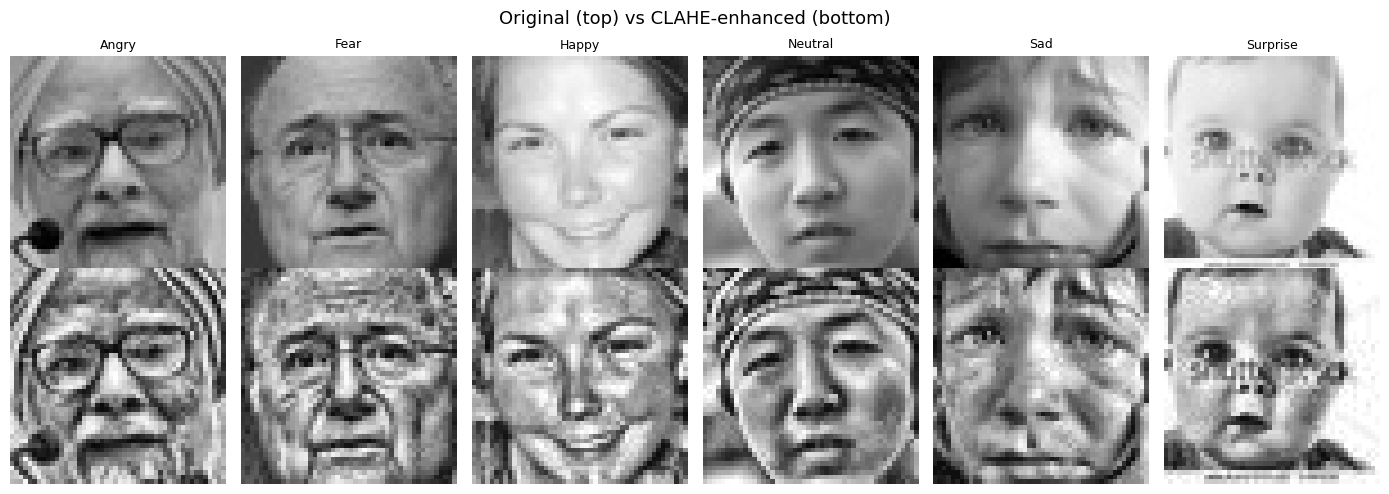

Saved: results/clahe_comparison.png


In [6]:
# ─── Visualise original vs CLAHE for one image per class ────────────────────
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Original (top) vs CLAHE-enhanced (bottom)', fontsize=13)

raw_tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.ToTensor(),
])

for col, cls in enumerate(CONFIG['classes']):
    cls_dir = os.path.join(CONFIG['data_root'], 'Training', cls)
    img_file = sorted(os.listdir(cls_dir))[0]
    img_path = os.path.join(cls_dir, img_file)

    pil_img = Image.open(img_path).convert('L')

    # Original
    axes[0, col].imshow(np.array(pil_img), cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(cls, fontsize=9)
    axes[0, col].axis('off')

    # CLAHE enhanced
    enhanced = preprocessor(pil_img)
    axes[1, col].imshow(np.array(enhanced), cmap='gray', vmin=0, vmax=255)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'clahe_comparison.png'), dpi=120)
plt.show()
print('Saved: results/clahe_comparison.png')

---
## Section 2 - Custom Neural Network

### 2.1 Modified Net Input Formula

A **modified net input** is used which includes both linear and quadratic terms sharing the same weights:

$$\text{net} = w_0 x_0 + w_0 x_0^2 + w_1 x_1 + w_1 x_1^2 + \ldots = \mathbf{W}(\mathbf{x} + \mathbf{x}^2)$$

This is implemented by computing $\mathbf{x} + \mathbf{x}^2$ (element-wise) before passing through a standard `nn.Linear` layer. The same weight matrix $\mathbf{W}$ thus contributes to both the linear and quadratic response, giving each neuron a non-linear input–output relationship even before the activation function.

### 2.2 Modified Activation Function

$$\sigma(\text{net}) = \frac{1}{1 + e^{-\text{net}}}$$

Standard sigmoid applied to the custom net input - implemented as `torch.sigmoid`.

### 2.3 Architecture Design Choices

- **BatchNorm before sigmoid**: The $x^2$ term can produce large positive pre-activations that push sigmoid into saturation (gradient ≈ 0). BatchNorm normalises activations before the sigmoid, maintaining gradient flow.
- **Gradient clipping** (`max_norm=1.0`): The $x^2$ Jacobian term can produce large gradients; clipping prevents exploding gradients during backpropagation.
- **Dropout**: Regularisation after each block to prevent overfitting on the 6,000-image training set.
- **Xavier initialisation**: Appropriate for the effective $x + x^2$ input scaling.

In [7]:
class CustomNetLayer(nn.Module):
    """Custom net input layer implementing: net = W @ (x + x²).

    The same weight matrix W is applied to both linear (x) and quadratic (x²)
    terms, as specified by the modified net input formula:
        net = w0*x0 + w0*x0² + w1*x1 + w1*x1² + ...
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x²: element-wise square; then W @ (x + x²)
        return self.linear(x + x ** 2)


class CustomSigmoid(nn.Module):
    """Custom activation: sigma(net) = 1 / (1 + exp(-net))."""

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(x)


class CustomBlock(nn.Module):
    """One hidden layer unit: CustomNetLayer → BatchNorm1d → CustomSigmoid → Dropout."""

    def __init__(self, in_features: int, out_features: int, dropout_rate: float = 0.3):
        super().__init__()
        self.layer = nn.Sequential(
            CustomNetLayer(in_features, out_features),
            nn.BatchNorm1d(out_features),   # stabilise before sigmoid
            CustomSigmoid(),
            nn.Dropout(p=dropout_rate),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)


class FERNet(nn.Module):
    """Facial Expression Recognition Network.

    Architecture:
        Input [batch, 1, 48, 48]
            → Flatten [batch, 2304]
            → N × CustomBlock(in → hidden_size)
            → CustomNetLayer(hidden_size → num_classes)   [raw logits]

    Args:
        num_layers:   number of hidden CustomBlocks
        hidden_size:  width of each hidden layer
        dropout_rate: dropout probability in each block
        num_classes:  output classes (default 6)
    """

    INPUT_DIM = 48 * 48  # 2304

    def __init__(self, num_layers: int = 3, hidden_size: int = 256,
                 dropout_rate: float = 0.3, num_classes: int = 6):
        super().__init__()
        self.num_layers  = num_layers
        self.hidden_size = hidden_size

        layers = []
        in_dim = self.INPUT_DIM
        for _ in range(num_layers):
            layers.append(CustomBlock(in_dim, hidden_size, dropout_rate))
            in_dim = hidden_size

        self.hidden = nn.Sequential(*layers)
        self.output = CustomNetLayer(in_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return raw logits (for use with nn.CrossEntropyLoss)."""
        x = x.view(x.size(0), -1)   # flatten: [batch, 2304]
        x = self.hidden(x)
        return self.output(x)

    def get_probabilities(self, x: torch.Tensor) -> torch.Tensor:
        """Return class probabilities (for inference only - do NOT use during training)."""
        logits = self.forward(x)
        return nn.functional.softmax(logits, dim=1)


def initialize_weights(model: nn.Module) -> None:
    """Xavier uniform initialisation for all Linear layers; zero biases."""
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

In [8]:
# ─── Unit test: verify CustomNetLayer produces W @ (x + x²) ─────────────────
torch.manual_seed(0)
test_layer = CustomNetLayer(3, 2, bias=False)
x_test = torch.tensor([[1.0, 2.0, 3.0]])

with torch.no_grad():
    out_custom = test_layer(x_test)
    out_manual = test_layer.linear(x_test + x_test ** 2)

assert torch.allclose(out_custom, out_manual), 'CustomNetLayer unit test FAILED'
print('CustomNetLayer unit test PASSED')
print(f'  x          = {x_test.tolist()[0]}')
print(f'  x + x²     = {(x_test + x_test**2).tolist()[0]}')
print(f'  W @ (x+x²) = {out_custom.tolist()[0]}')

# ─── Architecture summary ────────────────────────────────────────────────────
demo_net = FERNet(num_layers=3, hidden_size=256)
initialize_weights(demo_net)
total_params = sum(p.numel() for p in demo_net.parameters())
trainable    = sum(p.numel() for p in demo_net.parameters() if p.requires_grad)
print(f'\nFERNet(layers=3, hidden=256)')
print(f'  Total params    : {total_params:,}')
print(f'  Trainable params: {trainable:,}')

dummy = torch.zeros(4, 1, 48, 48)
logits = demo_net(dummy)
print(f'  Output shape    : {logits.shape}  (batch=4, classes=6)')
assert logits.shape == (4, 6), 'Shape mismatch'
print('Forward pass shape test PASSED')

CustomNetLayer unit test PASSED
  x          = [1.0, 2.0, 3.0]
  x + x²     = [2.0, 6.0, 12.0]
  W @ (x+x²) = [-3.8525736331939697, -0.3261542320251465]

FERNet(layers=3, hidden=256)
  Total params    : 724,742
  Trainable params: 724,742
  Output shape    : torch.Size([4, 6])  (batch=4, classes=6)
Forward pass shape test PASSED


---
## Section 3 - Training Infrastructure

In [9]:
class Trainer:
    """Manages the full training loop for FERNet.

    Optimiser : SGD with momentum and L2 weight decay
    Criterion : CrossEntropyLoss (applies log-softmax internally)
    Scheduler : StepLR - halves LR every 10 epochs
    Grad clip : clip_grad_norm_(max_norm=1.0) - necessary for x² gradient amplification
    """

    def __init__(self, model: FERNet, train_loader: DataLoader,
                 val_loader: DataLoader, lr: float = 0.01,
                 device: str = 'cpu', checkpoint_dir: str = 'checkpoints'):
        self.model          = model.to(device)
        self.train_loader   = train_loader
        self.val_loader     = val_loader
        self.device         = device
        self.checkpoint_dir = checkpoint_dir

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.SGD(
            model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=10, gamma=0.5)

        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss':   [], 'val_acc':   [],
        }
        self.best_val_acc = 0.0

    # ── one epoch ──────────────────────────────────────────────────────────
    def train_one_epoch(self) -> tuple:
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in self.train_loader:
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(images)
            loss   = self.criterion(logits, labels)
            loss.backward()

            # Clip gradients - x² terms can amplify gradient magnitudes
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

        return total_loss / total, correct / total

    # ── evaluation ─────────────────────────────────────────────────────────
    def evaluate(self, loader: DataLoader) -> tuple:
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                logits  = self.model(images)
                loss    = self.criterion(logits, labels)

                total_loss += loss.item() * images.size(0)
                correct    += (logits.argmax(1) == labels).sum().item()
                total      += images.size(0)

        return total_loss / total, correct / total

    # ── full training run ──────────────────────────────────────────────────
    def fit(self, epochs: int, verbose: bool = True) -> dict:
        for epoch in range(1, epochs + 1):
            tr_loss, tr_acc = self.train_one_epoch()
            va_loss, va_acc = self.evaluate(self.val_loader)
            self.scheduler.step()

            self.history['train_loss'].append(tr_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_loss'].append(va_loss)
            self.history['val_acc'].append(va_acc)

            if va_acc > self.best_val_acc:
                self.best_val_acc = va_acc
                self.save_checkpoint('best_model.pth')

            if verbose and (epoch % 5 == 0 or epoch == 1):
                lr_now = self.optimizer.param_groups[0]['lr']
                print(f'Epoch {epoch:3d}/{epochs} | '
                      f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
                      f'val loss {va_loss:.4f} acc {va_acc:.4f} | '
                      f'lr {lr_now:.5f}')

        return self.history

    # ── checkpoints ────────────────────────────────────────────────────────
    def save_checkpoint(self, filename: str) -> None:
        path = os.path.join(self.checkpoint_dir, filename)
        torch.save({
            'model_state_dict':     self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_val_acc':         self.best_val_acc,
            'num_layers':           self.model.num_layers,
            'hidden_size':          self.model.hidden_size,
        }, path)

    def load_checkpoint(self, filename: str) -> None:
        path = os.path.join(self.checkpoint_dir, filename)
        ckpt = torch.load(path, map_location=self.device)
        self.model.load_state_dict(ckpt['model_state_dict'])
        self.best_val_acc = ckpt.get('best_val_acc', 0.0)
        print(f'Loaded checkpoint: {filename}  (best_val_acc={self.best_val_acc:.4f})')

---
## Section 4 - Genetic Algorithm Hyperparameter Search

A genetic algorithm searches the discrete hyperparameter space defined below. Each **chromosome** is a list of 4 integers - indices into the respective value lists. The **fitness** of a chromosome is the best validation accuracy achieved when training a FERNet with those hyperparameters for `eval_epochs` epochs.

**Selection:** k-tournament (k=3) - avoids the diversity loss of pure rank selection.  
**Crossover:** single-point at 80% probability.  
**Mutation:** per-gene random replacement at `mutation_rate=0.2`.  
**Elitism:** top 2 individuals pass unchanged to the next generation.

In [10]:
GA_SEARCH_SPACE = {
    'learning_rate': [0.1,  0.05, 0.01, 0.005, 0.001, 0.0005],
    'batch_size':    [16,   32,   64,   128],
    'num_layers':    [1,    2,    3,    4,    5],
    'hidden_size':   [64,   128,  256,  512],
}

GA_KEYS = list(GA_SEARCH_SPACE.keys())


def decode_chromosome(chromosome: list) -> dict:
    """Convert index-chromosome to hyperparameter dict."""
    return {key: GA_SEARCH_SPACE[key][idx]
            for key, idx in zip(GA_KEYS, chromosome)}


class GeneticAlgorithmSearch:
    """Genetic Algorithm for FERNet hyperparameter optimisation.

    Chromosome encoding (4 genes):
        [lr_idx, bs_idx, nl_idx, hs_idx]
    """

    def __init__(self, config: dict, preprocessor: FERPreprocessor,
                 population_size: int = 12, num_generations: int = 8,
                 eval_epochs: int = 15, mutation_rate: float = 0.2):
        self.config          = config
        self.preprocessor    = preprocessor
        self.population_size = population_size
        self.num_generations = num_generations
        self.eval_epochs     = eval_epochs
        self.mutation_rate   = mutation_rate
        self.ga_log          = []

    # ── chromosome helpers ─────────────────────────────────────────────────
    def _random_chromosome(self) -> list:
        return [random.randint(0, len(GA_SEARCH_SPACE[k]) - 1)
                for k in GA_KEYS]

    # ── fitness evaluation ─────────────────────────────────────────────────
    def _fitness(self, chromosome: list) -> float:
        """Train FERNet for eval_epochs; return best validation accuracy."""
        params = decode_chromosome(chromosome)
        device = self.config['device']

        train_loader, val_loader, _ = build_dataloaders(
            self.config, params['batch_size'], self.preprocessor)

        model = FERNet(
            num_layers=params['num_layers'],
            hidden_size=params['hidden_size'],
            dropout_rate=0.3,
        )
        initialize_weights(model)

        trainer = Trainer(
            model, train_loader, val_loader,
            lr=params['learning_rate'],
            device=device,
            checkpoint_dir=self.config['checkpoint_dir'],
        )
        trainer.fit(epochs=self.eval_epochs, verbose=False)
        return trainer.best_val_acc

    # ── selection ──────────────────────────────────────────────────────────
    def _tournament_select(self, population: list, fitnesses: list, k: int = 3) -> list:
        """k-tournament selection - returns one chromosome."""
        competitors = random.sample(range(len(population)), k)
        winner = max(competitors, key=lambda i: fitnesses[i])
        return copy.deepcopy(population[winner])

    # ── crossover ──────────────────────────────────────────────────────────
    def _crossover(self, p1: list, p2: list, prob: float = 0.8) -> tuple:
        """Single-point crossover with probability `prob`."""
        if random.random() < prob:
            point = random.randint(1, len(p1) - 1)
            c1 = p1[:point] + p2[point:]
            c2 = p2[:point] + p1[point:]
        else:
            c1, c2 = copy.deepcopy(p1), copy.deepcopy(p2)
        return c1, c2

    # ── mutation ───────────────────────────────────────────────────────────
    def _mutate(self, chromosome: list) -> list:
        """Per-gene random replacement at mutation_rate."""
        return [
            random.randint(0, len(GA_SEARCH_SPACE[k]) - 1)
            if random.random() < self.mutation_rate
            else gene
            for gene, k in zip(chromosome, GA_KEYS)
        ]

    # ── main loop ──────────────────────────────────────────────────────────
    def run(self) -> dict:
        """Run the GA; return best hyperparameter dict."""
        print(f'GA: {self.population_size} individuals, '
              f'{self.num_generations} generations, '
              f'{self.eval_epochs} eval epochs each')
        print(f'Total training runs: '
              f'{self.population_size * self.num_generations}\n')

        # ── initialise population ─────────────────────────────────────────
        population = [self._random_chromosome()
                      for _ in range(self.population_size)]
        global_best_fitness   = 0.0
        global_best_chromosome = None

        for gen in range(1, self.num_generations + 1):
            print(f'Generation {gen}/{self.num_generations}')

            # Evaluate fitness
            fitnesses = []
            for i, chrom in enumerate(population):
                f = self._fitness(chrom)
                fitnesses.append(f)
                params_str = str(decode_chromosome(chrom))
                print(f'  [{i+1:2d}/{self.population_size}] '
                      f'fitness={f:.4f}  {params_str}')

            gen_best_idx = int(np.argmax(fitnesses))
            gen_best_fit = fitnesses[gen_best_idx]
            print(f'  >>> Gen {gen} best: {gen_best_fit:.4f} - '
                  f'{decode_chromosome(population[gen_best_idx])}')

            if gen_best_fit > global_best_fitness:
                global_best_fitness    = gen_best_fit
                global_best_chromosome = copy.deepcopy(population[gen_best_idx])

            # Log
            self.ga_log.append({
                'generation':    gen,
                'fitnesses':     fitnesses,
                'best_fitness':  gen_best_fit,
                'best_params':   decode_chromosome(population[gen_best_idx]),
            })

            if gen == self.num_generations:
                break

            # ── elitism: keep top 2 ───────────────────────────────────────
            sorted_idx = sorted(range(len(fitnesses)),
                                key=lambda i: fitnesses[i], reverse=True)
            elites = [copy.deepcopy(population[i]) for i in sorted_idx[:2]]

            # ── breed next generation ─────────────────────────────────────
            next_pop = elites[:]
            while len(next_pop) < self.population_size:
                p1 = self._tournament_select(population, fitnesses)
                p2 = self._tournament_select(population, fitnesses)
                c1, c2 = self._crossover(p1, p2)
                next_pop.append(self._mutate(c1))
                if len(next_pop) < self.population_size:
                    next_pop.append(self._mutate(c2))

            population = next_pop

        # ── save log ──────────────────────────────────────────────────────
        log_path = os.path.join(self.config['results_dir'], 'ga_log.json')
        with open(log_path, 'w') as f:
            json.dump(self.ga_log, f, indent=2)
        print(f'\nGA complete. Best fitness: {global_best_fitness:.4f}')
        print(f'Best params: {decode_chromosome(global_best_chromosome)}')
        print(f'GA log saved: {log_path}')

        return decode_chromosome(global_best_chromosome)

In [12]:
# ─── Run Genetic Algorithm ───────────────────────────────────────────────────
# NOTE: ~45-60 min on CPU, ~5-10 min on GPU.
# To skip, set SKIP_GA = True and define best_params manually below.
SKIP_GA = False

if not SKIP_GA:
    set_seed(CONFIG['seed'])
    ga = GeneticAlgorithmSearch(
        config=CONFIG,
        preprocessor=preprocessor,
        population_size=12,
        num_generations=8,
        eval_epochs=15,
        mutation_rate=0.2,
    )
    best_params = ga.run()
else:
    # Manual fallback - replace with actual GA results if rerunning
    best_params = {
        'learning_rate': 0.01,
        'batch_size':    64,
        'num_layers':    3,
        'hidden_size':   256,
    }
    print(f'GA skipped. Using params: {best_params}')

print(f'\nFinal best_params: {best_params}')

GA: 12 individuals, 8 generations, 15 eval epochs each
Total training runs: 96

Generation 1/8
  [ 1/12] fitness=0.3083  {'learning_rate': 0.0005, 'batch_size': 16, 'num_layers': 1, 'hidden_size': 256}
  [ 2/12] fitness=0.3167  {'learning_rate': 0.05, 'batch_size': 32, 'num_layers': 2, 'hidden_size': 64}
  [ 3/12] fitness=0.2183  {'learning_rate': 0.0005, 'batch_size': 16, 'num_layers': 5, 'hidden_size': 512}
  [ 4/12] fitness=0.3217  {'learning_rate': 0.1, 'batch_size': 16, 'num_layers': 1, 'hidden_size': 128}
  [ 5/12] fitness=0.2867  {'learning_rate': 0.05, 'batch_size': 16, 'num_layers': 5, 'hidden_size': 128}
  [ 6/12] fitness=0.2383  {'learning_rate': 0.0005, 'batch_size': 128, 'num_layers': 2, 'hidden_size': 512}
  [ 7/12] fitness=0.2917  {'learning_rate': 0.001, 'batch_size': 64, 'num_layers': 1, 'hidden_size': 128}
  [ 8/12] fitness=0.2183  {'learning_rate': 0.0005, 'batch_size': 128, 'num_layers': 3, 'hidden_size': 256}
  [ 9/12] fitness=0.2950  {'learning_rate': 0.05, 'batch

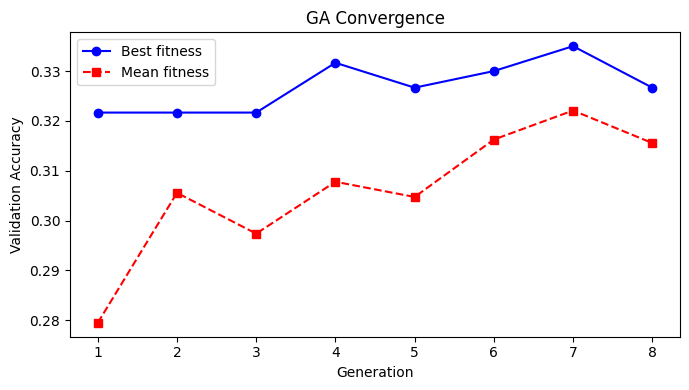

Saved: results/ga_convergence.png


In [13]:
# ─── Plot GA convergence ─────────────────────────────────────────────────────
if not SKIP_GA:
    gen_numbers  = [entry['generation'] for entry in ga.ga_log]
    best_per_gen = [entry['best_fitness'] for entry in ga.ga_log]
    mean_per_gen = [np.mean(entry['fitnesses']) for entry in ga.ga_log]

    plt.figure(figsize=(7, 4))
    plt.plot(gen_numbers, best_per_gen,  'b-o', label='Best fitness')
    plt.plot(gen_numbers, mean_per_gen,  'r--s', label='Mean fitness')
    plt.xlabel('Generation')
    plt.ylabel('Validation Accuracy')
    plt.title('GA Convergence')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['results_dir'], 'ga_convergence.png'), dpi=120)
    plt.show()
    print('Saved: results/ga_convergence.png')
else:
    print('GA was skipped - no convergence plot.')

---
## Section 5 - Final Training & Evaluation

In [14]:
def train_final_model(best_params: dict, config: dict,
                      preprocessor: FERPreprocessor,
                      full_epochs: int = 50) -> tuple:
    """Train FERNet for full_epochs using best GA hyperparameters.

    Returns:
        (model, history) where model weights are loaded from best_model.pth
    """
    set_seed(config['seed'])

    train_loader, val_loader, test_loader = build_dataloaders(
        config, best_params['batch_size'], preprocessor)

    model = FERNet(
        num_layers=best_params['num_layers'],
        hidden_size=best_params['hidden_size'],
        dropout_rate=0.3,
    )
    initialize_weights(model)

    trainer = Trainer(
        model, train_loader, val_loader,
        lr=best_params['learning_rate'],
        device=config['device'],
        checkpoint_dir=config['checkpoint_dir'],
    )

    print(f'Training final model for {full_epochs} epochs...')
    print(f'Params: {best_params}')
    history = trainer.fit(epochs=full_epochs, verbose=True)

    # Load the best checkpoint (saved during training on val_acc improvement)
    trainer.load_checkpoint('best_model.pth')
    print(f'\nBest val accuracy during training: {trainer.best_val_acc:.4f}')

    return trainer.model, history, train_loader, val_loader, test_loader

In [15]:
final_model, history, train_loader, val_loader, test_loader = train_final_model(
    best_params, CONFIG, preprocessor, full_epochs=50)

Training final model for 50 epochs...
Params: {'learning_rate': 0.1, 'batch_size': 16, 'num_layers': 1, 'hidden_size': 64}
Epoch   1/50 | train loss 2.1509 acc 0.1838 | val loss 1.9556 acc 0.2200 | lr 0.10000
Epoch   5/50 | train loss 1.7476 acc 0.2565 | val loss 1.7201 acc 0.2500 | lr 0.10000
Epoch  10/50 | train loss 1.7188 acc 0.2677 | val loss 1.6992 acc 0.2783 | lr 0.05000
Epoch  15/50 | train loss 1.7033 acc 0.2787 | val loss 1.6759 acc 0.3133 | lr 0.05000
Epoch  20/50 | train loss 1.6941 acc 0.2830 | val loss 1.6702 acc 0.3083 | lr 0.02500
Epoch  25/50 | train loss 1.6750 acc 0.2965 | val loss 1.6382 acc 0.3283 | lr 0.02500
Epoch  30/50 | train loss 1.6784 acc 0.2922 | val loss 1.6360 acc 0.3283 | lr 0.01250
Epoch  35/50 | train loss 1.6568 acc 0.3038 | val loss 1.6269 acc 0.3483 | lr 0.01250
Epoch  40/50 | train loss 1.6576 acc 0.2988 | val loss 1.6245 acc 0.3433 | lr 0.00625
Epoch  45/50 | train loss 1.6568 acc 0.3025 | val loss 1.6178 acc 0.3417 | lr 0.00625
Epoch  50/50 | tr

In [16]:
class Evaluator:
    """Computes and visualises evaluation metrics for a trained FERNet."""

    def __init__(self, model: FERNet, config: dict, device: str = 'cpu'):
        self.model   = model
        self.config  = config
        self.device  = device
        self.classes = config['classes']

    def predict_all(self, loader: DataLoader) -> tuple:
        """Return (y_true, y_pred) as numpy arrays."""
        self.model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                logits = self.model(images)
                preds  = logits.argmax(1).cpu().numpy()
                y_true.extend(labels.numpy())
                y_pred.extend(preds)
        return np.array(y_true), np.array(y_pred)

    def compute_metrics(self, loader: DataLoader, split_name: str = '') -> float:
        """Print accuracy + per-class classification report; return accuracy."""
        y_true, y_pred = self.predict_all(loader)
        acc = accuracy_score(y_true, y_pred)
        header = f'  {split_name} ' if split_name else '  '
        print(f'{header}Accuracy: {acc:.4f}  ({int(acc*len(y_true))}/{len(y_true)})')
        print(classification_report(
            y_true, y_pred,
            target_names=self.classes, digits=4))
        return acc

    def plot_confusion_matrix(self, loader: DataLoader,
                               split_name: str = 'Test') -> None:
        """Plot and save normalised confusion matrix."""
        y_true, y_pred = self.predict_all(loader)
        cm = confusion_matrix(y_true, y_pred)

        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm, display_labels=self.classes)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'Confusion Matrix - {split_name} Set')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        path = os.path.join(self.config['results_dir'],
                            f'confusion_matrix_{split_name.lower()}.png')
        plt.savefig(path, dpi=120)
        plt.show()
        print(f'Saved: {path}')
        print(f'Row sums (should equal {len(self.classes)*100} total): {cm.sum(axis=1).tolist()}')

    def plot_training_history(self, history: dict) -> None:
        """Plot loss and accuracy curves for train and validation."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        epochs = range(1, len(history['train_loss']) + 1)

        ax1.plot(epochs, history['train_loss'], 'b-', label='Train')
        ax1.plot(epochs, history['val_loss'],   'r-', label='Validation')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training & Validation Loss')
        ax1.legend()

        ax2.plot(epochs, history['train_acc'], 'b-', label='Train')
        ax2.plot(epochs, history['val_acc'],   'r-', label='Validation')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Training & Validation Accuracy')
        ax2.legend()

        plt.suptitle('Final Model Training Curves', fontsize=13)
        plt.tight_layout()
        path = os.path.join(self.config['results_dir'], 'training_curves.png')
        plt.savefig(path, dpi=120)
        plt.show()
        print(f'Saved: {path}')

In [17]:
# ─── Evaluate on all three splits ───────────────────────────────────────────
evaluator = Evaluator(final_model, CONFIG, device=CONFIG['device'])

print('=' * 60)
print('TRAINING SET')
train_acc = evaluator.compute_metrics(train_loader, 'Training')

print('=' * 60)
print('VALIDATION SET')
val_acc = evaluator.compute_metrics(val_loader, 'Validation')

print('=' * 60)
print('TEST SET  (primary reported metric)')
test_acc = evaluator.compute_metrics(test_loader, 'Test')
print('=' * 60)

TRAINING SET
  Training Accuracy: 0.3277  (1966/6000)
              precision    recall  f1-score   support

       Angry     0.2715    0.3090    0.2891      1000
        Fear     0.2615    0.1650    0.2023      1000
       Happy     0.4175    0.3920    0.4043      1000
     Neutral     0.4217    0.1940    0.2658      1000
         Sad     0.2515    0.4670    0.3269      1000
    Surprise     0.4503    0.4390    0.4446      1000

    accuracy                         0.3277      6000
   macro avg     0.3457    0.3277    0.3222      6000
weighted avg     0.3457    0.3277    0.3222      6000

VALIDATION SET
  Validation Accuracy: 0.3533  (212/600)
              precision    recall  f1-score   support

       Angry     0.2719    0.3100    0.2897       100
        Fear     0.2714    0.1900    0.2235       100
       Happy     0.4896    0.4700    0.4796       100
     Neutral     0.4151    0.2200    0.2876       100
         Sad     0.2803    0.3700    0.3190       100
    Surprise     0.414

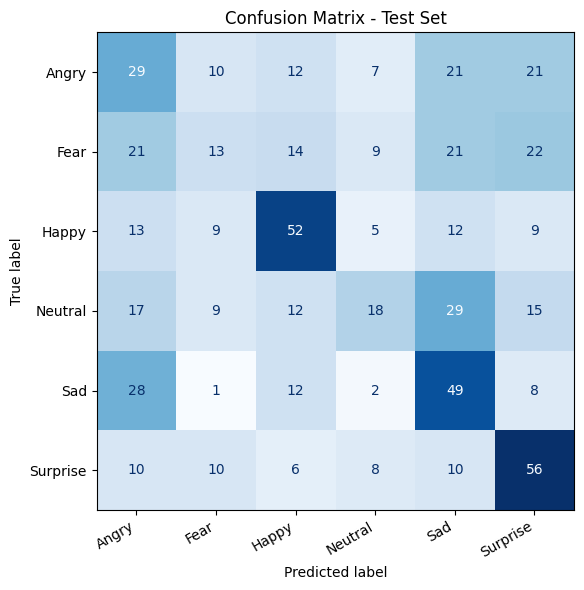

Saved: c:\Users\USER\Documents\AI_CW2\results\confusion_matrix_test.png
Row sums (should equal 600 total): [100, 100, 100, 100, 100, 100]


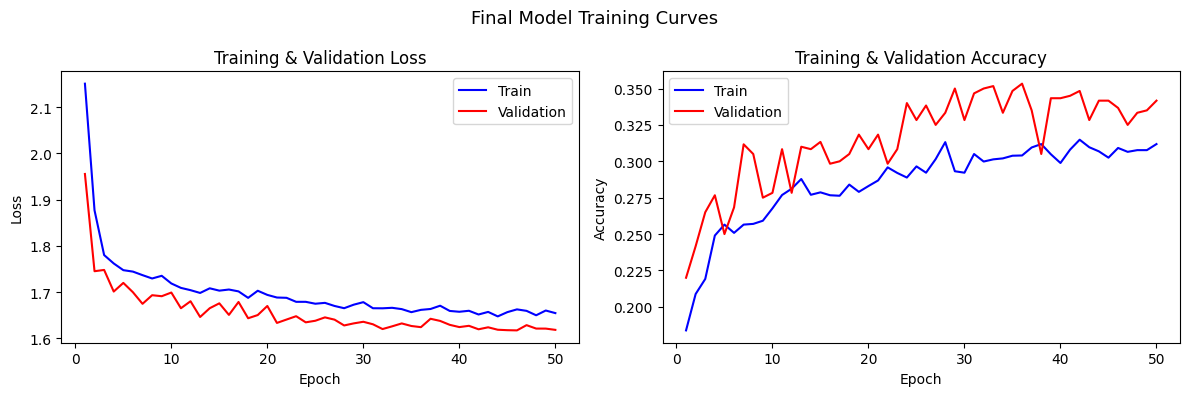

Saved: c:\Users\USER\Documents\AI_CW2\results\training_curves.png


In [18]:
# ─── Confusion matrix & training curves ─────────────────────────────────────
evaluator.plot_confusion_matrix(test_loader, split_name='Test')
evaluator.plot_training_history(history)

---
## Section 6 - Cross-Validation Assessment

5-fold Stratified K-Fold cross-validation is performed on the combined Training + Validation dataset (6,600 images) using the best GA hyperparameters. Stratification ensures each fold preserves the class distribution.

In [19]:
class FERDatasetFromPaths(Dataset):
    """Dataset that loads images from explicit file path + label lists.

    Used for cross-validation where we need to construct arbitrary train/val
    splits from combined file paths.
    """

    def __init__(self, paths: list, labels: list, transform):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        img   = Image.open(self.paths[idx]).convert('L')
        img   = self.transform(img)
        label = self.labels[idx]
        return img, label


def load_all_file_paths(data_root: str, splits: list, classes: list) -> tuple:
    """Collect all file paths and integer labels from ImageFolder-style structure.

    Args:
        data_root: root data directory
        splits:    list of split folder names, e.g. ['Training', 'Validation']
        classes:   ordered list of class names (defines label indices)

    Returns:
        (paths: list[str], labels: list[int])
    """
    paths, labels = [], []
    class_to_idx  = {cls: i for i, cls in enumerate(classes)}

    for split in splits:
        for cls in classes:
            cls_dir = os.path.join(data_root, split, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in sorted(os.listdir(cls_dir)):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    paths.append(os.path.join(cls_dir, fname))
                    labels.append(class_to_idx[cls])

    return paths, labels

In [20]:
def run_cross_validation(best_params: dict, config: dict,
                          preprocessor: FERPreprocessor,
                          n_folds: int = 5, cv_epochs: int = 30) -> list:
    """5-fold stratified cross-validation on Training + Validation data.

    Returns:
        fold_accuracies: list of float (one per fold)
    """
    print(f'Loading all file paths (Training + Validation)...')
    all_paths, all_labels = load_all_file_paths(
        config['data_root'],
        splits=['Training', 'Validation'],
        classes=config['classes'],
    )
    print(f'Total samples: {len(all_paths)}  '
          f'(expected 6,600 = 6 classes × 1,100)')

    eval_tf = build_transforms(preprocessor, augment=False)
    skf     = StratifiedKFold(n_splits=n_folds, shuffle=True,
                               random_state=config['seed'])

    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(
            skf.split(all_paths, all_labels), start=1):
        print(f'\n--- Fold {fold}/{n_folds} '
              f'(train={len(train_idx)}, val={len(val_idx)}) ---')

        train_paths  = [all_paths[i] for i in train_idx]
        train_labels = [all_labels[i] for i in train_idx]
        val_paths    = [all_paths[i] for i in val_idx]
        val_labels   = [all_labels[i] for i in val_idx]

        # Augmented transform for CV training folds
        aug_tf = build_transforms(preprocessor, augment=True)

        fold_train_ds = FERDatasetFromPaths(train_paths, train_labels, aug_tf)
        fold_val_ds   = FERDatasetFromPaths(val_paths,   val_labels,   eval_tf)

        fold_train_loader = DataLoader(
            fold_train_ds, batch_size=best_params['batch_size'],
            shuffle=True, num_workers=0)
        fold_val_loader   = DataLoader(
            fold_val_ds, batch_size=best_params['batch_size'],
            shuffle=False, num_workers=0)

        model = FERNet(
            num_layers=best_params['num_layers'],
            hidden_size=best_params['hidden_size'],
            dropout_rate=0.3,
        )
        initialize_weights(model)

        trainer = Trainer(
            model, fold_train_loader, fold_val_loader,
            lr=best_params['learning_rate'],
            device=config['device'],
            checkpoint_dir=config['checkpoint_dir'],
        )
        trainer.fit(epochs=cv_epochs, verbose=True)

        fold_acc = trainer.best_val_acc
        fold_accuracies.append(fold_acc)
        print(f'Fold {fold} best val accuracy: {fold_acc:.4f}')

    print(f'\n{"="*50}')
    print(f'Cross-Validation Results ({n_folds} folds):')
    for i, acc in enumerate(fold_accuracies, 1):
        print(f'  Fold {i}: {acc:.4f}')
    print(f'  Mean : {np.mean(fold_accuracies):.4f}')
    print(f'  Std  : {np.std(fold_accuracies):.4f}')
    print(f'  => CV Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}')

    return fold_accuracies

In [21]:
# ─── Run 5-fold cross-validation ────────────────────────────────────────────
fold_accuracies = run_cross_validation(
    best_params, CONFIG, preprocessor, n_folds=5, cv_epochs=30)

Loading all file paths (Training + Validation)...
Total samples: 6600  (expected 6,600 = 6 classes × 1,100)

--- Fold 1/5 (train=5280, val=1320) ---
Epoch   1/30 | train loss 2.1617 acc 0.1975 | val loss 2.0166 acc 0.1947 | lr 0.10000
Epoch   5/30 | train loss 1.7522 acc 0.2449 | val loss 1.6835 acc 0.3068 | lr 0.10000
Epoch  10/30 | train loss 1.7304 acc 0.2672 | val loss 1.6741 acc 0.3068 | lr 0.05000
Epoch  15/30 | train loss 1.7097 acc 0.2771 | val loss 1.6320 acc 0.3295 | lr 0.05000
Epoch  20/30 | train loss 1.7017 acc 0.2794 | val loss 1.6381 acc 0.3220 | lr 0.02500
Epoch  25/30 | train loss 1.6848 acc 0.2905 | val loss 1.6277 acc 0.3371 | lr 0.02500
Epoch  30/30 | train loss 1.6855 acc 0.2924 | val loss 1.6153 acc 0.3432 | lr 0.01250
Fold 1 best val accuracy: 0.3462

--- Fold 2/5 (train=5280, val=1320) ---
Epoch   1/30 | train loss 2.1445 acc 0.1938 | val loss 1.7880 acc 0.2265 | lr 0.10000
Epoch   5/30 | train loss 1.7475 acc 0.2489 | val loss 1.7118 acc 0.2598 | lr 0.10000
Epo

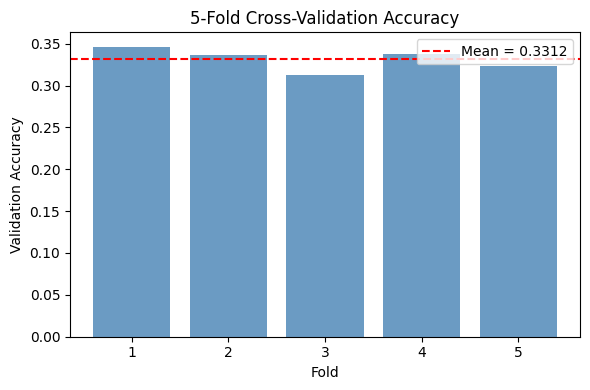

Saved: c:\Users\USER\Documents\AI_CW2\results\cv_results.png


In [22]:
# ─── CV results plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
folds = range(1, len(fold_accuracies) + 1)
ax.bar(folds, fold_accuracies, color='steelblue', alpha=0.8)
ax.axhline(np.mean(fold_accuracies), color='red', linestyle='--',
           label=f'Mean = {np.mean(fold_accuracies):.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Validation Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.set_xticks(list(folds))
ax.legend()
plt.tight_layout()
cv_plot_path = os.path.join(CONFIG['results_dir'], 'cv_results.png')
plt.savefig(cv_plot_path, dpi=120)
plt.show()
print(f'Saved: {cv_plot_path}')

---
## Section 7 - Inference Module & Demo

In [23]:
class FERInference:
    """Production-ready inference wrapper for FERNet.

    Accepts images as file paths, numpy arrays, or PIL Images.
    Loads a saved checkpoint and runs evaluation-mode inference.
    """

    def __init__(self, model_path: str, config: dict,
                 preprocessor: FERPreprocessor,
                 num_layers: int, hidden_size: int):
        self.config      = config
        self.classes     = config['classes']
        self.device      = config['device']
        self.transform   = build_transforms(preprocessor, augment=False)

        # Build and load model
        self.model = FERNet(
            num_layers=num_layers,
            hidden_size=hidden_size,
            dropout_rate=0.0,   # disable dropout for inference
        ).to(self.device)

        ckpt = torch.load(model_path, map_location=self.device)
        self.model.load_state_dict(ckpt['model_state_dict'])
        self.model.eval()
        print(f'Loaded model from {model_path}')

    def _load_image(self, image_input) -> Image.Image:
        """Normalise any input type to a grayscale PIL Image."""
        if isinstance(image_input, str):
            return Image.open(image_input).convert('L')
        elif isinstance(image_input, np.ndarray):
            if image_input.ndim == 3:
                image_input = cv2.cvtColor(image_input, cv2.COLOR_BGR2GRAY)
            return Image.fromarray(image_input.astype(np.uint8))
        elif isinstance(image_input, Image.Image):
            return image_input.convert('L')
        else:
            raise TypeError(f'Unsupported input type: {type(image_input)}')

    def predict(self, image_input) -> tuple:
        """Predict emotion for a single image.

        Returns:
            (predicted_label: str, confidence: float, all_probs: dict)
        """
        pil_img = self._load_image(image_input)
        tensor  = self.transform(pil_img).unsqueeze(0).to(self.device)

        with torch.no_grad():
            probs = self.model.get_probabilities(tensor)[0].cpu().numpy()

        pred_idx   = int(probs.argmax())
        pred_label = self.classes[pred_idx]
        confidence = float(probs[pred_idx])
        all_probs  = {cls: float(p) for cls, p in zip(self.classes, probs)}

        return pred_label, confidence, all_probs

    def predict_batch(self, image_list: list) -> list:
        """Predict emotions for a list of images.

        Returns:
            List of (predicted_label, confidence, all_probs) tuples
        """
        return [self.predict(img) for img in image_list]

In [24]:
# ─── Load inference engine ───────────────────────────────────────────────────
inference = FERInference(
    model_path=os.path.join(CONFIG['checkpoint_dir'], 'best_model.pth'),
    config=CONFIG,
    preprocessor=preprocessor,
    num_layers=best_params['num_layers'],
    hidden_size=best_params['hidden_size'],
)

Loaded model from c:\Users\USER\Documents\AI_CW2\checkpoints\best_model.pth


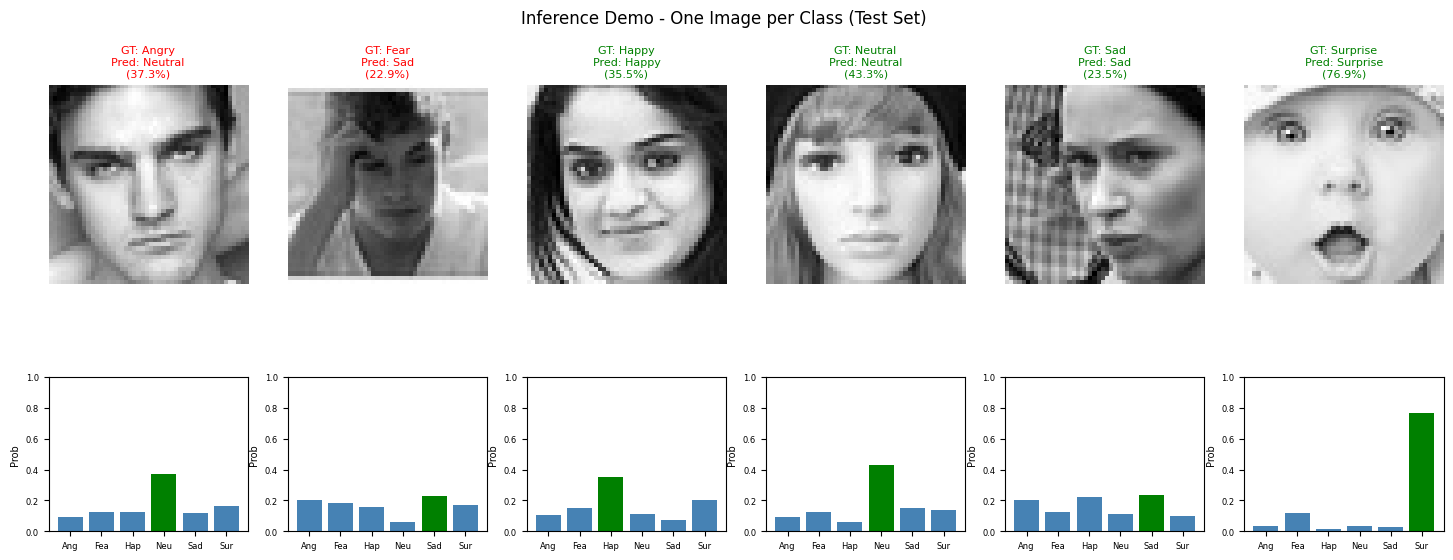

Saved: c:\Users\USER\Documents\AI_CW2\results\inference_demo.png

Inference Demo Results:
     Class   Predicted  Confidence  Correct
------------------------------------------------
     Angry     Neutral      37.3%  ✗
      Fear         Sad      22.9%  ✗
     Happy       Happy      35.5%  ✓
   Neutral     Neutral      43.3%  ✓
       Sad         Sad      23.5%  ✓
  Surprise    Surprise      76.9%  ✓

Demo accuracy: 4/6


In [25]:
# ─── Demo: one image per class from test set ─────────────────────────────────
demo_images, demo_labels, demo_paths = [], [], []
for cls in CONFIG['classes']:
    cls_dir  = os.path.join(CONFIG['data_root'], 'Testing', cls)
    img_file = sorted(os.listdir(cls_dir))[0]
    img_path = os.path.join(cls_dir, img_file)
    demo_paths.append(img_path)
    demo_labels.append(cls)

demo_results = inference.predict_batch(demo_paths)

# ── Figure: image + confidence bar chart per class ───────────────────────────
n_cols   = len(CONFIG['classes'])
fig      = plt.figure(figsize=(18, 6))
gs       = gridspec.GridSpec(2, n_cols, height_ratios=[1.5, 1], hspace=0.4)

for col, (path, gt, (pred, conf, probs)) in enumerate(
        zip(demo_paths, demo_labels, demo_results)):

    # Image panel
    ax_img = fig.add_subplot(gs[0, col])
    img    = Image.open(path).convert('L')
    color  = 'green' if pred == gt else 'red'
    ax_img.imshow(np.array(img), cmap='gray')
    ax_img.set_title(f'GT: {gt}\nPred: {pred}\n({conf:.1%})',
                     fontsize=8, color=color)
    ax_img.axis('off')

    # Probability bar chart
    ax_bar  = fig.add_subplot(gs[1, col])
    bar_cls = list(probs.keys())
    bar_val = list(probs.values())
    bars    = ax_bar.bar(range(len(bar_cls)), bar_val,
                         color=['green' if c == pred else 'steelblue'
                                for c in bar_cls])
    ax_bar.set_xticks(range(len(bar_cls)))
    ax_bar.set_xticklabels([c[:3] for c in bar_cls], fontsize=6)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_ylabel('Prob', fontsize=7)
    ax_bar.tick_params(axis='y', labelsize=6)

plt.suptitle('Inference Demo - One Image per Class (Test Set)', fontsize=12)
demo_path = os.path.join(CONFIG['results_dir'], 'inference_demo.png')
plt.savefig(demo_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {demo_path}')

# ── Text summary ─────────────────────────────────────────────────────────────
print('\nInference Demo Results:')
print(f'{"Class":>10}  {"Predicted":>10}  {"Confidence":>10}  {"Correct"}')
print('-' * 48)
correct_count = 0
for gt, (pred, conf, _) in zip(demo_labels, demo_results):
    ok = pred == gt
    correct_count += ok
    print(f'{gt:>10}  {pred:>10}  {conf:>9.1%}  {"✓" if ok else "✗"}')
print(f'\nDemo accuracy: {correct_count}/{len(demo_labels)}')

In [26]:
# ─── Final summary ───────────────────────────────────────────────────────────
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'Best hyperparameters (from GA):')
for k, v in best_params.items():
    print(f'  {k:>15}: {v}')
print(f'\nModel architecture:')
print(f'  num_layers  : {best_params["num_layers"]}')
print(f'  hidden_size : {best_params["hidden_size"]}')
print(f'  input_dim   : {FERNet.INPUT_DIM} (48×48 flattened)')
print(f'  formula     : W @ (x + x²)  [custom net input]')
print(f'  activation  : sigma(net) = 1/(1+exp(-net))')
print(f'\nTest accuracy : {test_acc:.4f}')
print(f'Val  accuracy : {val_acc:.4f}')
print(f'Train accuracy: {train_acc:.4f}')
if 'fold_accuracies' in dir():
    print(f'CV accuracy   : {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}')
print('=' * 60)

FINAL RESULTS SUMMARY
Best hyperparameters (from GA):
    learning_rate: 0.1
       batch_size: 16
       num_layers: 1
      hidden_size: 64

Model architecture:
  num_layers  : 1
  hidden_size : 64
  input_dim   : 2304 (48×48 flattened)
  formula     : W @ (x + x²)  [custom net input]
  activation  : sigma(net) = 1/(1+exp(-net))

Test accuracy : 0.3617
Val  accuracy : 0.3533
Train accuracy: 0.3277
CV accuracy   : 0.3312 ± 0.0120
